# Mezcla de gaussianas (GMM) sobre los embeddings del EDA

Réplica del análisis de `hc_clustering.ipynb` cambiando el algoritmo: en lugar de
clustering jerárquico (Ward), se ajusta una **mezcla de gaussianas (GMM)** por técnica.

La motivación es el **soft clustering**: un artículo de prensa puede pertenecer a más de
un tema a la vez (p. ej. una nota sobre el presupuesto estatal es a la vez economía y
política). HC asigna cada artículo a exactamente un clúster; la GMM entrega una
**probabilidad de pertenencia a cada componente** (responsabilidades), lo que permite
cuantificar esa ambigüedad temática además de producir una partición dura (argmax)
comparable con la de HC.

| Técnica | Representación usada para la GMM |
|---|---|
| TF-IDF | TruncatedSVD a 50 componentes (LSA) sobre la matriz sparse |
| MiniLM multilingüe | 384 dims, L2-normalizados, PCA a 50 |
| BGE-M3 (vLLM) | 1024 dims, L2-normalizados, PCA a 50 |
| BETO (chunking + pooling) | 768 dims, L2-normalizados, PCA a 50 |
| BETO whitened | 128 dims centradas y descorrelacionadas, L2-normalizadas, PCA a 50 |
| Nemotron VL (solo texto) | 2048 dims, L2-normalizados, PCA a 50 |

Diferencias metodológicas frente a `hc_clustering.ipynb`:

- **Reducción previa con PCA a 50 dims.** Una GMM con covarianza `full` estima
  `k · d(d+3)/2` parámetros: con d = 2048 (Nemotron VL) y ~1,512 documentos el modelo es
  inestimable. Se reduce cada representación a 50 componentes — la misma reducción previa
  que el EDA y los notebooks HC usan para t-SNE — donde la estimación de covarianzas es
  viable.
- **Selección de modelo con BIC**, el criterio nativo de la GMM: penaliza los parámetros,
  así que compara de forma honesta covarianzas `full`, `diag` y `tied` y distintos k.
- Silhouette, Calinski-Harabasz y Davies-Bouldin se calculan sobre las **etiquetas duras**
  (argmax) y sobre el **espacio de embedding original L2-normalizado**, el mismo donde se
  midieron en HC, para que las cifras sean directamente comparables entre notebooks.
- No hay dendrogramas ni correlación cofenética (no aplican a GMM). La sección de
  subclusters se reemplaza por el **análisis de pertenencias blandas**: qué artículos
  quedan repartidos entre componentes y entre qué temas.

Se mantienen las secciones de control de artefacto de longitud (η²) y de métricas
supervisadas contra `seccion`, idénticas a las de HC.


In [1]:
%cd "/home/pherrera/projects/clustering_n_rag_u_index/notebooks"
%pwd

/home/pherrera/projects/clustering_n_rag_u_index/notebooks


'/home/pherrera/projects/clustering_n_rag_u_index/notebooks'

In [2]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))

PALETA = ["#2a78d6", "#008300", "#e87ba4", "#c9761a", "#7b5ea7", "#c0392b"]
sns.set_theme(style="whitegrid", palette=PALETA)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.color": "#e1e0d9",
                     "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e"})
RANDOM_STATE = 42


def rejilla(n: int, ancho: float = 5.3, alto: float = 4.5, ncols: int = 3):
    """Rejilla de `n` paneles en `ncols` columnas; oculta los ejes sobrantes.

    Con seis técnicas una sola fila haría figuras de ~32 pulgadas de ancho,
    ilegibles al renderizar; el envoltorio en filas mantiene el tamaño por panel.
    """
    nfilas = -(-n // ncols)
    fig, axes = plt.subplots(nfilas, ncols, figsize=(ancho * ncols, alto * nfilas))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes[n:]:
        ax.set_visible(False)
    return fig, axes[:n]


## Reproducción de la submuestra del EDA

Se replica exactamente la submuestra estratificada de ~1,500 artículos del EDA
(misma limpieza, mismos estratos año × periódico, mismo `random_state`) y se verifica
contra los `id_articulo` guardados en `data/embeddings/muestra_ids.npy` para garantizar
que los embeddings cacheados corresponden a estos textos.

In [3]:
import re
from math import ceil

data = pd.read_csv("../data/raw/stratified_sample_2019_2026.csv")
data.drop(columns=["anio", "id_pressreader", "id_periodico", "icor_index", "icor_v2_index"], inplace=True)
data["fecha"] = pd.to_datetime(data["fecha"])
data["anio"] = data["fecha"].dt.year


def norm_text(text: str) -> str:
    """Normaliza un texto: minúsculas y colapso de espacios en blanco."""
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


data["texto_norm"] = data["texto"].map(norm_text)

N_MUESTRA = 1500
estratos = data.groupby(["nombre_periodico", "anio"])
cuota = ceil(N_MUESTRA / estratos.ngroups)
muestra = pd.concat(
    [g.sample(min(len(g), cuota), random_state=RANDOM_STATE) for _, g in estratos]
).sort_values(["anio", "nombre_periodico", "id_articulo"]).reset_index(drop=True)

textos_emb = (muestra["titulo"].fillna("").map(norm_text) + ". "
              + muestra["texto_norm"]).str.slice(0, 2000).tolist()

EMB_DIR = Path("../data/embeddings")
ids_muestra = muestra["id_articulo"].to_numpy()
assert np.array_equal(np.load(EMB_DIR / "muestra_ids.npy"), ids_muestra), \
    "La submuestra no coincide con la usada en el EDA: recalcular embeddings en eda.ipynb"
print(f"Submuestra reproducida: {len(muestra)} artículos — ids verificados contra el caché")


Submuestra reproducida: 1512 artículos — ids verificados contra el caché


## Carga de embeddings

MiniLM y BGE-M3 se cargan del caché generado por `eda.ipynb`; TF-IDF (que el EDA no
cachea por ser sparse) se recalcula con los mismos hiperparámetros y se reduce con
`TruncatedSVD` a 50 componentes, la misma reducción previa que el EDA usa para t-SNE.

**BETO** (`dccuchile/bert-base-spanish-wwm-cased`, 768 dims) se carga del caché que genera
`scripts/embed_beto.py`. A diferencia de las demás técnicas, no ve un texto truncado: cada
artículo se parte en ventanas solapadas de 512 tokens (el límite de contexto de BETO) y los
vectores de chunk se promedian (ver `src/embeddings/beto.py`).

Se probó *attention pooling* inter-chunk y se descartó por indistinguible de la media en
este corpus (coseno 0.9999, r = 0.9988 entre matrices de distancia): los artículos de
prensa apenas exceden la ventana de BETO — **mediana de 1 chunk, 65% en un solo chunk** —
así que el pooling casi nunca combina más de dos vectores.
**Nemotron VL** (`nvidia/llama-nemotron-embed-vl-1b-v2`, 2048 dims) se carga del caché que
genera `scripts/embed_nemotron.py`. Es un modelo multimodal (Llama 3.2 1B + SigLip2, ~1.7 B
parámetros) del que aquí se usa **solo la rama de texto**: el corpus no tiene imágenes de
página. Como su ventana evaluada es de 10,240 tokens y el artículo más largo del corpus
ronda los 6,900, cada artículo entra completo **en un solo forward pass** — es la única
técnica que cubre el texto íntegro sin truncarlo ni promediar chunks.

Advertencia al interpretarlo: fue entrenado con aprendizaje contrastivo para *retrieval*
(emparejar una consulta con la página que la responde), no para medir similitud entre pares
de documentos, que es lo que pide el clustering. Su ventaja frente a BETO en las métricas
mezcla dos cosas — fine-tuning contrastivo y cobertura del texto completo — y la sección de
η² ayuda a separarlas.


In [4]:
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

vectorizador = TfidfVectorizer(max_features=50_000, min_df=3, max_df=0.6, sublinear_tf=True)
emb_tfidf_sparse = vectorizador.fit_transform(textos_emb)
emb_tfidf = TruncatedSVD(n_components=50, random_state=RANDOM_STATE).fit_transform(emb_tfidf_sparse)

emb_st = np.load(EMB_DIR / "minilm_multilingual.npy")
emb_bge = np.load(EMB_DIR / "bge_m3.npy")
emb_beto = np.load(EMB_DIR / "beto.npy")
emb_nemotron = np.load(EMB_DIR / "nemotron.npy")

# L2-normalización: euclídea sobre vectores unitarios ~ distancia coseno
embeddings = {
    "TF-IDF (SVD-50)": normalize(emb_tfidf),
    "MiniLM multilingüe": normalize(emb_st),
    "BGE-M3": normalize(emb_bge),
    "BETO": normalize(emb_beto),
    "Nemotron VL": normalize(emb_nemotron),
}
for nombre, emb in embeddings.items():
    print(f"{nombre}: {emb.shape}")


TF-IDF (SVD-50): (1512, 50)
MiniLM multilingüe: (1512, 384)
BGE-M3: (1512, 1024)
BETO: (1512, 768)
Nemotron VL: (1512, 2048)


### Whitening del espacio de BETO

BETO no tiene fine-tuning contrastivo, y su espacio es **anisotrópico**: todos los vectores
se concentran en un cono estrecho, con coseno medio de ~0.94 entre artículos tomados al azar
(economía vs. deportes deberían ser casi ortogonales). La causa es una **dirección común** a
todos los embeddings, heredada del preentrenamiento, que domina el producto punto y entierra
la señal temática. Como el silhouette es un cociente entre separación y dispersión, un rango
de distancias comprimido lo penaliza aunque la estructura exista.

El *whitening* (Su et al., 2021) corrige esto con una transformación lineal: centra los
vectores (elimina la dirección común) y aplica `W = Σ^(-1/2)`, dejando la covarianza en la
identidad — la nube pasa de cigarro alargado a esfera, y las direcciones de baja varianza,
donde viven las distinciones finas entre temas, se amplifican hasta pesar como las dominantes.

`Σ` se estima del propio corpus: con 1,512 documentos y 768 dimensiones hay menos muestras que
parámetros de covarianza, así que la estimación es ruidosa. Por eso se retienen solo
`N_COMP = 128` componentes (las de mayor varianza), que mitiga el ruido y actúa como el
*all-but-the-top* de Mu & Viswanath en su versión suave.

Se añade como técnica aparte para que la comparación con BETO sin whitening quede medida en
el mismo cuadro de métricas.

In [5]:
N_COMP = 128


def whitening(emb: np.ndarray, n_comp: int = N_COMP) -> np.ndarray:
    """Centra y descorrelaciona `emb`, reteniendo las `n_comp` direcciones de mayor varianza."""
    mu = emb.mean(axis=0)
    centrado = emb - mu
    # SVD de la covarianza: U son las direcciones principales, s sus varianzas.
    U, s, _ = np.linalg.svd(np.cov(centrado, rowvar=False))
    W = U[:, :n_comp] / np.sqrt(s[:n_comp])  # Sigma^(-1/2) truncada
    return centrado @ W


emb_beto_w = whitening(emb_beto)
embeddings["BETO (whitened)"] = normalize(emb_beto_w)

# Efecto sobre la anisotropia: coseno medio entre pares de documentos distintos.
for nombre in ("BETO", "BETO (whitened)"):
    X = embeddings[nombre]
    cos = (X @ X.T)[np.triu_indices(len(X), k=1)]
    print(f"{nombre}: coseno medio entre documentos = {cos.mean():.3f} "
          f"(desv. {cos.std():.3f}, rango [{cos.min():.2f}, {cos.max():.2f}])")


BETO: coseno medio entre documentos = 0.937 (desv. 0.029, rango [0.67, 0.99])
BETO (whitened): coseno medio entre documentos = -0.000 (desv. 0.087, rango [-0.38, 0.89])


## Reducción previa con PCA para la GMM

Cada representación se reduce a `DIM_GMM = 50` componentes principales (las que ya tienen
≤ 50 dims se usan tal cual). La GMM se ajusta sobre este espacio; las métricas de
silhouette se calculan después sobre el embedding original para mantener la
comparabilidad con `hc_clustering.ipynb`.


In [6]:
from sklearn.decomposition import PCA

DIM_GMM = 50

X_gmm = {}
for nombre, emb in embeddings.items():
    X_gmm[nombre] = (emb if emb.shape[1] <= DIM_GMM
                     else PCA(n_components=DIM_GMM, random_state=RANDOM_STATE).fit_transform(emb))
    print(f"{nombre}: {emb.shape[1]} dims → GMM sobre {X_gmm[nombre].shape[1]}")


TF-IDF (SVD-50): 50 dims → GMM sobre 50
MiniLM multilingüe: 384 dims → GMM sobre 50
BGE-M3: 1024 dims → GMM sobre 50
BETO: 768 dims → GMM sobre 50
Nemotron VL: 2048 dims → GMM sobre 50
BETO (whitened): 128 dims → GMM sobre 50


## Ajuste de la GMM y selección de modelo (BIC)

Para cada técnica se ajustan mezclas con k = 2…15 componentes y tres estructuras de
covarianza (`full`, `diag`, `tied`), con 3 reinicios de EM por configuración. El **BIC**
(↓ mejor) penaliza el número de parámetros, así que permite comparar covarianzas de
distinta complejidad sin favorecer mecánicamente a la más flexible. Por técnica se fija
la covarianza del modelo con menor BIC global y, con ella, se guardan las
responsabilidades y las etiquetas duras para todo el rango de k — el equivalente de los
cortes del dendrograma en HC.


In [7]:
from sklearn.mixture import GaussianMixture

RANGO_K = range(2, 16)
COV_TYPES = ["full", "diag", "tied"]

filas, gmms = [], {}
for nombre, X in X_gmm.items():
    for cov in COV_TYPES:
        for k in RANGO_K:
            gmm = GaussianMixture(n_components=k, covariance_type=cov, n_init=3,
                                  reg_covar=1e-6, random_state=RANDOM_STATE)
            gmm.fit(X)
            gmms[(nombre, cov, k)] = gmm
            filas.append({"tecnica": nombre, "covarianza": cov, "k": k,
                          "bic": gmm.bic(X), "aic": gmm.aic(X),
                          "convergio": gmm.converged_})
    print(f"{nombre}: {len(COV_TYPES) * len(RANGO_K)} modelos ajustados")

modelos_gmm = pd.DataFrame(filas)


TF-IDF (SVD-50): 42 modelos ajustados
MiniLM multilingüe: 42 modelos ajustados
BGE-M3: 42 modelos ajustados
BETO: 42 modelos ajustados
Nemotron VL: 42 modelos ajustados
BETO (whitened): 42 modelos ajustados


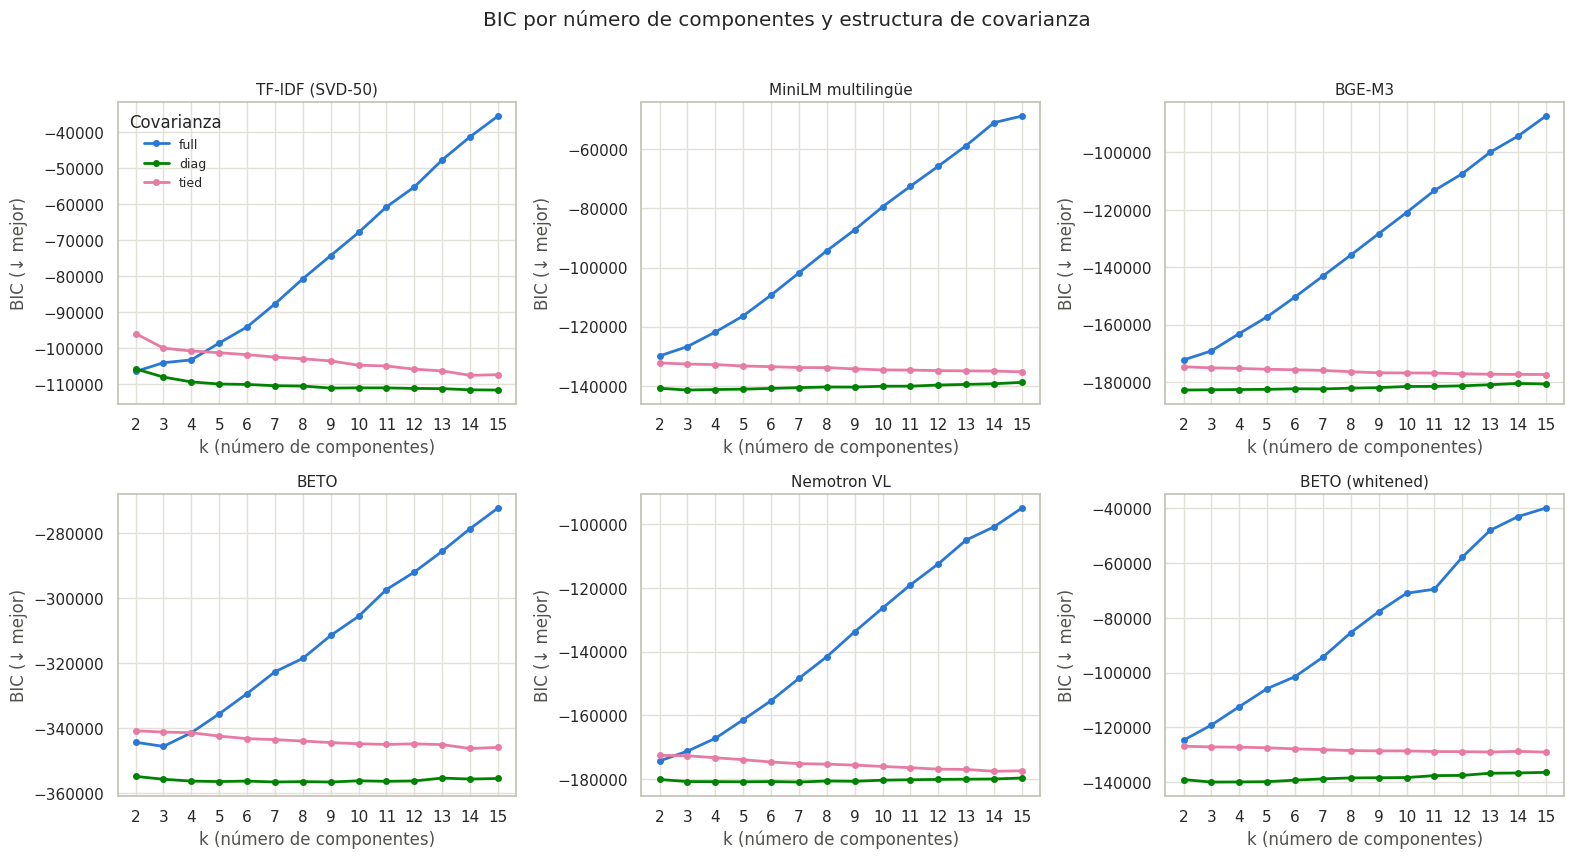

In [8]:
fig, axes = rejilla(len(X_gmm), alto=4.2)
for ax, nombre in zip(axes, X_gmm):
    sub = modelos_gmm[modelos_gmm["tecnica"] == nombre]
    for color, (cov, g) in zip(PALETA, sub.groupby("covarianza", sort=False)):
        ax.plot(g["k"], g["bic"], marker="o", markersize=4, linewidth=2,
                color=color, label=cov)
    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel("k (número de componentes)")
    ax.set_ylabel("BIC (↓ mejor)")
    ax.set_xticks(list(RANGO_K))
axes[0].legend(frameon=False, fontsize=9, title="Covarianza")
plt.suptitle("BIC por número de componentes y estructura de covarianza", y=1.02)
plt.tight_layout()
plt.show()


In [9]:
# Covarianza óptima por técnica: la del modelo con menor BIC en todo el rango de k
idx_bic = modelos_gmm.loc[modelos_gmm.groupby("tecnica", sort=False)["bic"].idxmin()]
cov_optima = idx_bic.set_index("tecnica")["covarianza"]
k_bic = idx_bic.set_index("tecnica")["k"].astype(int)

etiquetas_por_k, resp_por_k = {}, {}
for nombre, X in X_gmm.items():
    cov = cov_optima[nombre]
    for k in RANGO_K:
        resp = gmms[(nombre, cov, k)].predict_proba(X)
        resp_por_k[(nombre, k)] = resp
        etiquetas_por_k[(nombre, k)] = resp.argmax(axis=1) + 1  # 1-indexado, como en HC
    print(f"{nombre}: covarianza óptima = {cov}, k óptimo por BIC = {k_bic[nombre]}")


TF-IDF (SVD-50): covarianza óptima = diag, k óptimo por BIC = 15
MiniLM multilingüe: covarianza óptima = diag, k óptimo por BIC = 3
BGE-M3: covarianza óptima = diag, k óptimo por BIC = 2
BETO: covarianza óptima = diag, k óptimo por BIC = 9
Nemotron VL: covarianza óptima = diag, k óptimo por BIC = 7
BETO (whitened): covarianza óptima = diag, k óptimo por BIC = 3


## Métricas no supervisadas por número de clústeres

Para cada técnica se toman las etiquetas duras de la GMM (covarianza óptima) con
k = 2…15 y se calculan silhouette (coseno), Calinski-Harabasz y Davies-Bouldin sobre
el **espacio de embedding original L2-normalizado** — el mismo donde se midieron en `hc_clustering.ipynb` — aunque la GMM se haya ajustado sobre la reducción PCA, para que los valores sean comparables con `hc_clustering.ipynb`.


In [10]:
from sklearn.metrics import (calinski_harabasz_score, davies_bouldin_score,
                             silhouette_score)

filas = []
for nombre in X_gmm:
    emb = embeddings[nombre]
    for k in RANGO_K:
        etiquetas = etiquetas_por_k[(nombre, k)]
        filas.append({
            "tecnica": nombre,
            "k": k,
            "silhouette": silhouette_score(emb, etiquetas, metric="cosine"),
            "calinski_harabasz": calinski_harabasz_score(emb, etiquetas),
            "davies_bouldin": davies_bouldin_score(emb, etiquetas),
        })

metricas = pd.DataFrame(filas)
metricas.head()


,tecnica,k,silhouette,calinski_harabasz,davies_bouldin
0,TF-IDF (SVD-50),2,0.106504,69.777760,3.759759
1,TF-IDF (SVD-50),3,0.128491,73.804289,2.809594
2,TF-IDF (SVD-50),4,0.092697,67.201987,3.424020
3,TF-IDF (SVD-50),5,0.104737,62.242729,3.454712
4,TF-IDF (SVD-50),6,0.110083,56.846123,3.534616


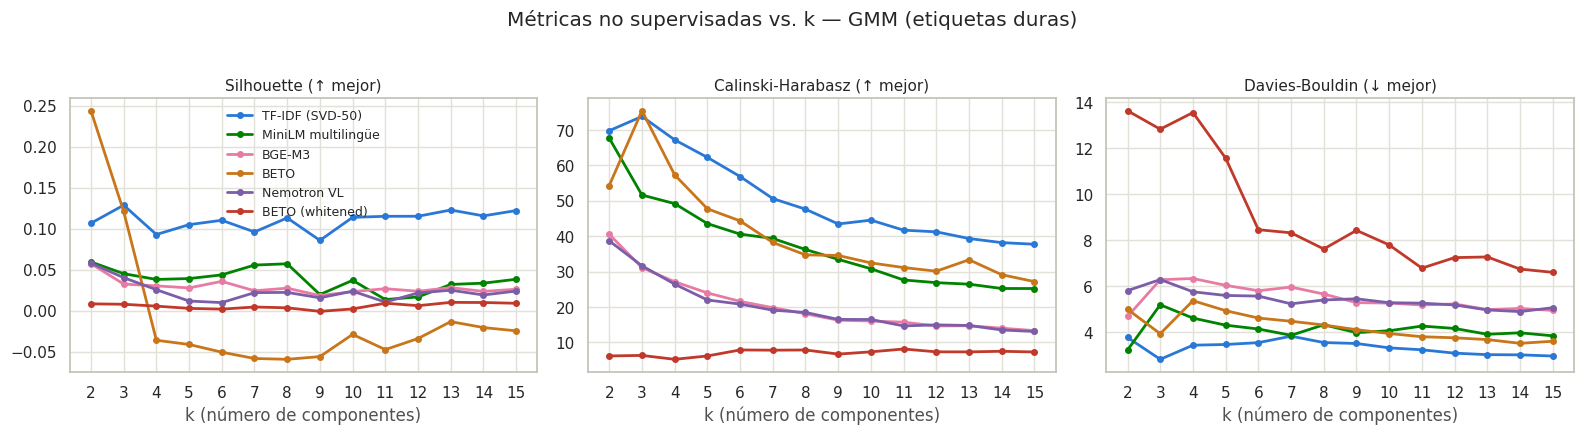

In [11]:
COLORES_TEC = dict(zip(X_gmm, PALETA))
config_metricas = [("silhouette", "Silhouette (↑ mejor)"),
                   ("calinski_harabasz", "Calinski-Harabasz (↑ mejor)"),
                   ("davies_bouldin", "Davies-Bouldin (↓ mejor)")]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, (col, titulo) in zip(axes, config_metricas):
    for nombre in X_gmm:
        serie = metricas[metricas["tecnica"] == nombre]
        ax.plot(serie["k"], serie[col], marker="o", markersize=4, linewidth=2,
                color=COLORES_TEC[nombre], label=nombre)
    ax.set_xlabel("k (número de componentes)")
    ax.set_title(titulo, fontsize=11)
    ax.set_xticks(list(RANGO_K))
axes[0].legend(frameon=False, fontsize=9)
plt.suptitle("Métricas no supervisadas vs. k — GMM (etiquetas duras)", y=1.03)
plt.tight_layout()
plt.show()


## Resumen: mejor k por técnica

Se elige el k que maximiza silhouette — el mismo criterio que en los notebooks HC, para
comparar cortes equivalentes — y se reporta junto al **k óptimo por BIC**, el criterio
nativo de la GMM. Si difieren mucho conviene recordar qué mide cada uno: el BIC premia
el mejor modelo de **densidad** (puede preferir más componentes para cubrir una nube
alargada), mientras que silhouette premia la **separación** de la partición dura.


In [12]:
mejores = (metricas.loc[metricas.groupby("tecnica")["silhouette"].idxmax()]
           .set_index("tecnica").round(3))
mejores["k_bic"] = k_bic
mejores["covarianza"] = cov_optima
mejores


,k,silhouette,calinski_harabasz,davies_bouldin,k_bic,covarianza
tecnica,,,,,,
BETO,2,0.244,54.308,4.983,9,diag
BETO (whitened),13,0.010,7.332,7.261,3,diag
BGE-M3,2,0.057,40.529,4.672,2,diag
MiniLM multilingüe,2,0.059,67.673,3.214,3,diag
Nemotron VL,2,0.058,38.676,5.797,7,diag
TF-IDF (SVD-50),3,0.128,73.804,2.810,15,diag


In [13]:
for nombre in X_gmm:
    k = int(mejores.loc[nombre, "k"])
    tam = np.bincount(etiquetas_por_k[(nombre, k)])[1:].tolist()
    print(f"{nombre} (k={k}): tamaños de clúster = {sorted(tam, reverse=True)}")


TF-IDF (SVD-50) (k=3): tamaños de clúster = [1173, 264, 75]
MiniLM multilingüe (k=2): tamaños de clúster = [1277, 235]
BGE-M3 (k=2): tamaños de clúster = [1232, 280]
BETO (k=2): tamaños de clúster = [1101, 411]
Nemotron VL (k=2): tamaños de clúster = [1038, 474]
BETO (whitened) (k=13): tamaños de clúster = [444, 239, 120, 109, 99, 94, 91, 77, 69, 54, 41, 39, 36]


## ¿Los clústeres separan por tema o por longitud del artículo?

**BETO y Nemotron VL** son las dos técnicas que **no ven un texto truncado**: las demás
cortan a 2,000 caracteres. Pero lo hacen de forma distinta, y esa diferencia es la que
permite aislar el artefacto:

- **BETO** recorre el artículo en ventanas de 512 tokens y **promedia** los vectores de
  chunk. Ese promedio introduce una dependencia mecánica con la longitud — un artículo de
  un chunk conserva su vector; uno de cinco queda cerca del centroide del corpus,
  simplemente por promediar más.
- **Nemotron VL** procesa el artículo completo **de una sola pasada** (ventana de 10,240
  tokens), sin promediar nada. Ve la misma cantidad de texto que BETO, sin el promediado.

Si el clustering se apoya en la longitud, el silhouette sube sin que la partición sea
temática. Se mide con **η²**: la fracción de la varianza de la longitud del artículo que
explica la partición en clústeres. η² alto significa que saber el clúster predice la
longitud, es decir, que los clústeres están ordenados por tamaño de artículo. Se acompaña
de un test de Kruskal-Wallis (no paramétrico, la longitud es muy asimétrica) y se calcula
para **todas** las técnicas, para que los valores se lean contra una línea base.


In [14]:
from scipy.stats import kruskal

longitudes = muestra["texto_norm"].str.len().to_numpy()


def eta_cuadrado(valores: np.ndarray, grupos: np.ndarray) -> float:
    """Fracción de la varianza de `valores` explicada por la partición `grupos`."""
    media = valores.mean()
    ss_entre = sum(
        (grupos == g).sum() * (valores[grupos == g].mean() - media) ** 2
        for g in np.unique(grupos)
    )
    return ss_entre / ((valores - media) ** 2).sum()


filas = []
for nombre in X_gmm:
    k = int(mejores.loc[nombre, "k"])
    etiquetas = etiquetas_por_k[(nombre, k)]
    por_cluster = [longitudes[etiquetas == c] for c in np.unique(etiquetas)]
    medianas = [np.median(g) for g in por_cluster]
    filas.append({
        "tecnica": nombre,
        "k": k,
        "eta2_longitud": round(eta_cuadrado(longitudes, etiquetas), 3),
        "p_kruskal": f"{kruskal(*por_cluster).pvalue:.1e}",
        "silhouette": mejores.loc[nombre, "silhouette"],
        # Rango de medianas entre clústeres: cuánto se separan en caracteres.
        "mediana_min": int(min(medianas)),
        "mediana_max": int(max(medianas)),
    })

efecto_longitud = pd.DataFrame(filas).set_index("tecnica")
efecto_longitud


,k,eta2_longitud,p_kruskal,silhouette,mediana_min,mediana_max
tecnica,,,,,,
TF-IDF (SVD-50),3,0.037,4.6e-19,0.128,381,1785
MiniLM multilingüe,2,0.014,3.2e-04,0.059,1288,1690
BGE-M3,2,0.017,1.4e-05,0.057,1294,1713
BETO,2,0.245,6.4e-131,0.244,379,2059
Nemotron VL,2,0.060,2.2e-23,0.058,1171,1893
BETO (whitened),13,0.409,3.2e-155,0.010,148,3401


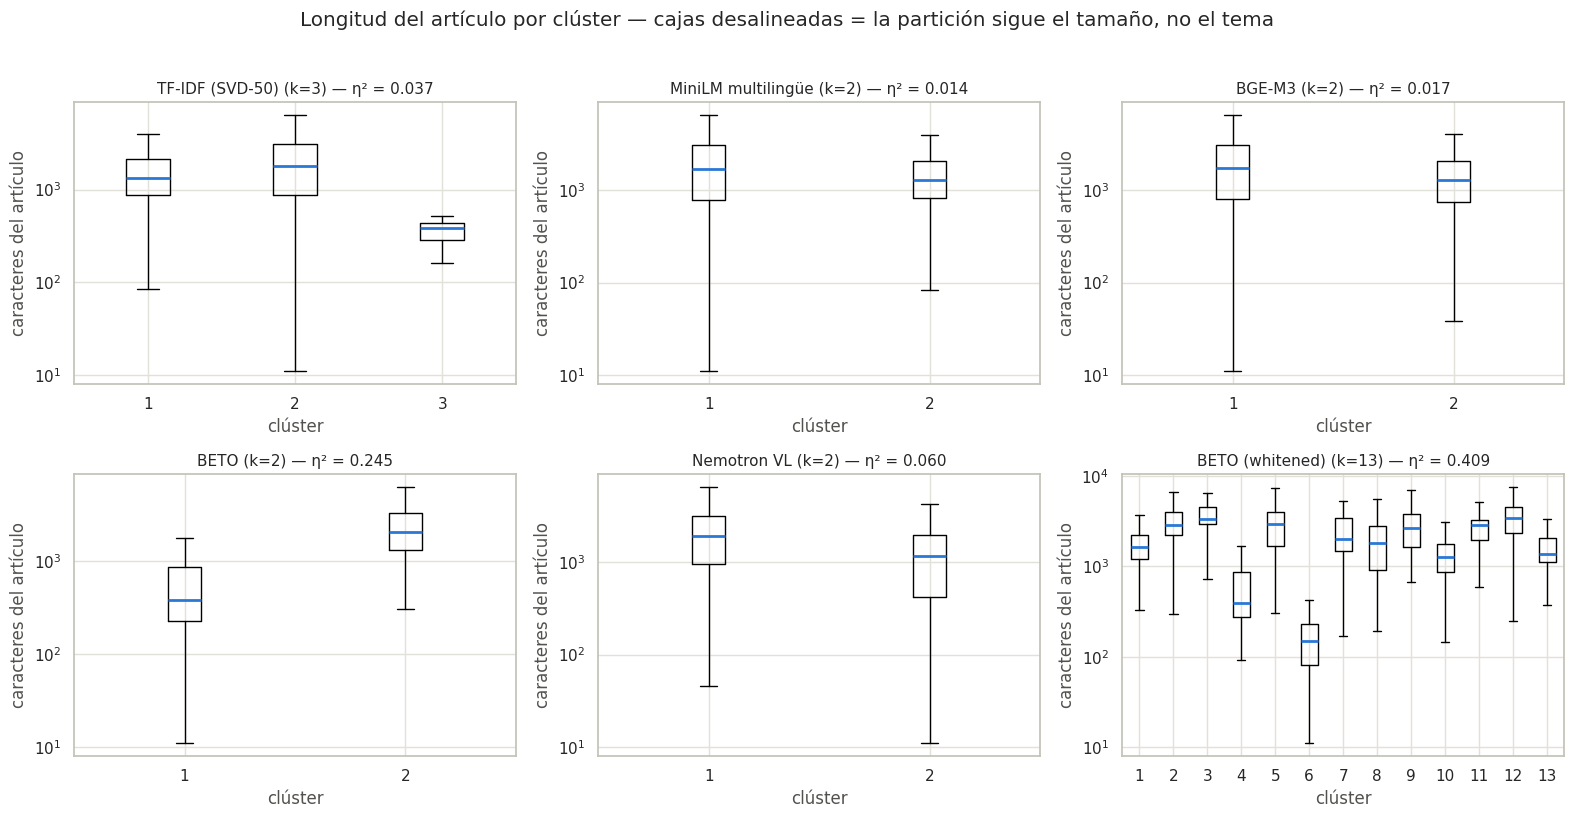

In [15]:
fig, axes = rejilla(len(X_gmm), alto=4.0)
for ax, nombre in zip(axes, X_gmm):
    k = int(mejores.loc[nombre, "k"])
    etiquetas = etiquetas_por_k[(nombre, k)]
    ax.boxplot([longitudes[etiquetas == c] for c in np.unique(etiquetas)],
               showfliers=False, medianprops={"color": "#2a78d6", "linewidth": 2})
    ax.set_yscale("log")
    ax.set_title(f"{nombre} (k={k}) — η² = {efecto_longitud.loc[nombre, 'eta2_longitud']:.3f}",
                 fontsize=11)
    ax.set_xlabel("clúster")
    ax.set_ylabel("caracteres del artículo")
plt.suptitle("Longitud del artículo por clúster — cajas desalineadas = la partición sigue el tamaño, no el tema",
             y=1.02)
plt.tight_layout()
plt.show()


### Cómo leer esta sección

El eje y está en escala logarítmica porque la longitud de los artículos abarca varios
órdenes de magnitud. La lectura es directa:

- **Cajas alineadas entre clústeres (η² bajo, ~0.0–0.05)** — la partición es indiferente a
  la longitud; el silhouette que obtenga esa técnica se debe a otra cosa (idealmente, tema).
- **Cajas escalonadas (η² alto, > 0.2)** — los clústeres están ordenados por tamaño de
  artículo. Un silhouette alto en ese escenario **no acredita calidad temática**: separar
  textos largos de cortos es una partición fácil y muy compacta en el espacio.

El contraste decisivo es **BETO vs. Nemotron VL** contra las tres técnicas truncadas,
porque separa cobertura de promediado:

- **BETO alto, Nemotron VL bajo** — el artefacto lo produce el promediado de chunks, no el
  hecho de leer el artículo completo. La ventaja de BETO en silhouette (si la hay) no es
  temática y la comparación debe apoyarse en ARI/AMI contra sección.
- **Ambos altos** — lo que ordena los clústeres es la cobertura del texto largo en sí, no
  la mecánica del pooling.
- **Ambos comparables a las truncadas** — no hay artefacto de longitud y los silhouettes
  son interpretables tal cual.

Este contraste **debe leerse de la ejecución**, no darse por sabido: sin correr estas
celdas la conclusión no está respaldada.


## Métricas supervisadas por número de clústeres (sección como label)

Se usa la sección del artículo (`seccion`) como etiqueta de referencia externa y se
evalúan los cortes k = 2…15 con ARI, AMI, homogeneidad, completitud y V-measure.
Las secciones son muy granulares (cientos de valores distintos entre periódicos),
por lo que se privilegian las métricas ajustadas por azar (ARI, AMI), que no
premian la mera fragmentación.

In [16]:
from sklearn.metrics import (adjusted_mutual_info_score, adjusted_rand_score,
                             completeness_score, homogeneity_score, v_measure_score)

secciones = muestra["seccion"].fillna("(sin sección)").to_numpy()
print(f"Secciones distintas en la submuestra: {pd.Series(secciones).nunique()}")

filas = []
for nombre in X_gmm:
    for k in RANGO_K:
        etiquetas = etiquetas_por_k[(nombre, k)]
        filas.append({
            "tecnica": nombre,
            "k": k,
            "ari": adjusted_rand_score(secciones, etiquetas),
            "ami": adjusted_mutual_info_score(secciones, etiquetas),
            "homogeneidad": homogeneity_score(secciones, etiquetas),
            "completitud": completeness_score(secciones, etiquetas),
            "v_measure": v_measure_score(secciones, etiquetas),
        })

metricas_sup = pd.DataFrame(filas)
metricas_sup.head()

Secciones distintas en la submuestra: 213


,tecnica,k,ari,ami,homogeneidad,completitud,v_measure
0,TF-IDF (SVD-50),2,0.015790,0.093116,0.070851,0.516691,0.124614
1,TF-IDF (SVD-50),3,0.020821,0.131712,0.101254,0.586709,0.172704
2,TF-IDF (SVD-50),4,0.042567,0.157815,0.141434,0.475566,0.218026
3,TF-IDF (SVD-50),5,0.057584,0.176439,0.169988,0.457113,0.247818
4,TF-IDF (SVD-50),6,0.071202,0.185007,0.189235,0.442857,0.265165


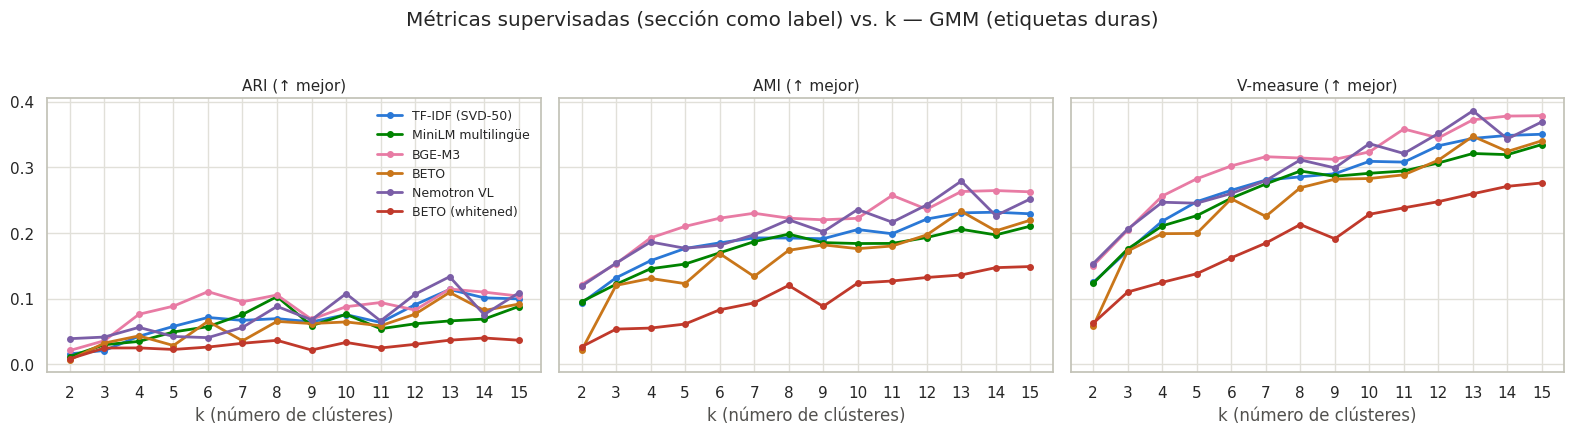

Métricas supervisadas en el k óptimo (por silhouette) de cada técnica:


,k,ari,ami,homogeneidad,completitud,v_measure
tecnica,,,,,,
TF-IDF (SVD-50),3,0.021,0.132,0.101,0.587,0.173
MiniLM multilingüe,2,0.012,0.095,0.069,0.599,0.123
BGE-M3,2,0.021,0.121,0.085,0.667,0.150
BETO,2,0.007,0.021,0.033,0.215,0.058
Nemotron VL,2,0.039,0.119,0.089,0.542,0.153
BETO (whitened),13,0.037,0.136,0.208,0.347,0.260


In [17]:
config_sup = [("ari", "ARI (↑ mejor)"), ("ami", "AMI (↑ mejor)"),
              ("v_measure", "V-measure (↑ mejor)")]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
for ax, (col, titulo) in zip(axes, config_sup):
    for nombre in embeddings:
        serie = metricas_sup[metricas_sup["tecnica"] == nombre]
        ax.plot(serie["k"], serie[col], marker="o", markersize=4, linewidth=2,
                color=COLORES_TEC[nombre], label=nombre)
    ax.set_xlabel("k (número de clústeres)")
    ax.set_title(titulo, fontsize=11)
    ax.set_xticks(list(RANGO_K))
axes[0].legend(frameon=False, fontsize=9)
plt.suptitle("Métricas supervisadas (sección como label) vs. k — GMM (etiquetas duras)", y=1.03)
plt.tight_layout()
plt.show()

resumen_sup = (metricas_sup.merge(mejores.reset_index()[["tecnica", "k"]].astype({"k": int}),
                                  on=["tecnica", "k"])
               .set_index("tecnica").round(3))
print("Métricas supervisadas en el k óptimo (por silhouette) de cada técnica:")
resumen_sup

## Visualización de los cortes óptimos (t-SNE)

Proyección t-SNE 2D coloreada por la componente GMM (etiqueta dura) en el mejor k de
cada técnica. Los puntos con **aro gris** son los de asignación ambigua (probabilidad
máxima < 0.6): la información que HC no puede dar. Si se concentran en las fronteras
entre nubes, la GMM está capturando exactamente los artículos multi-tema que motivan
este notebook.


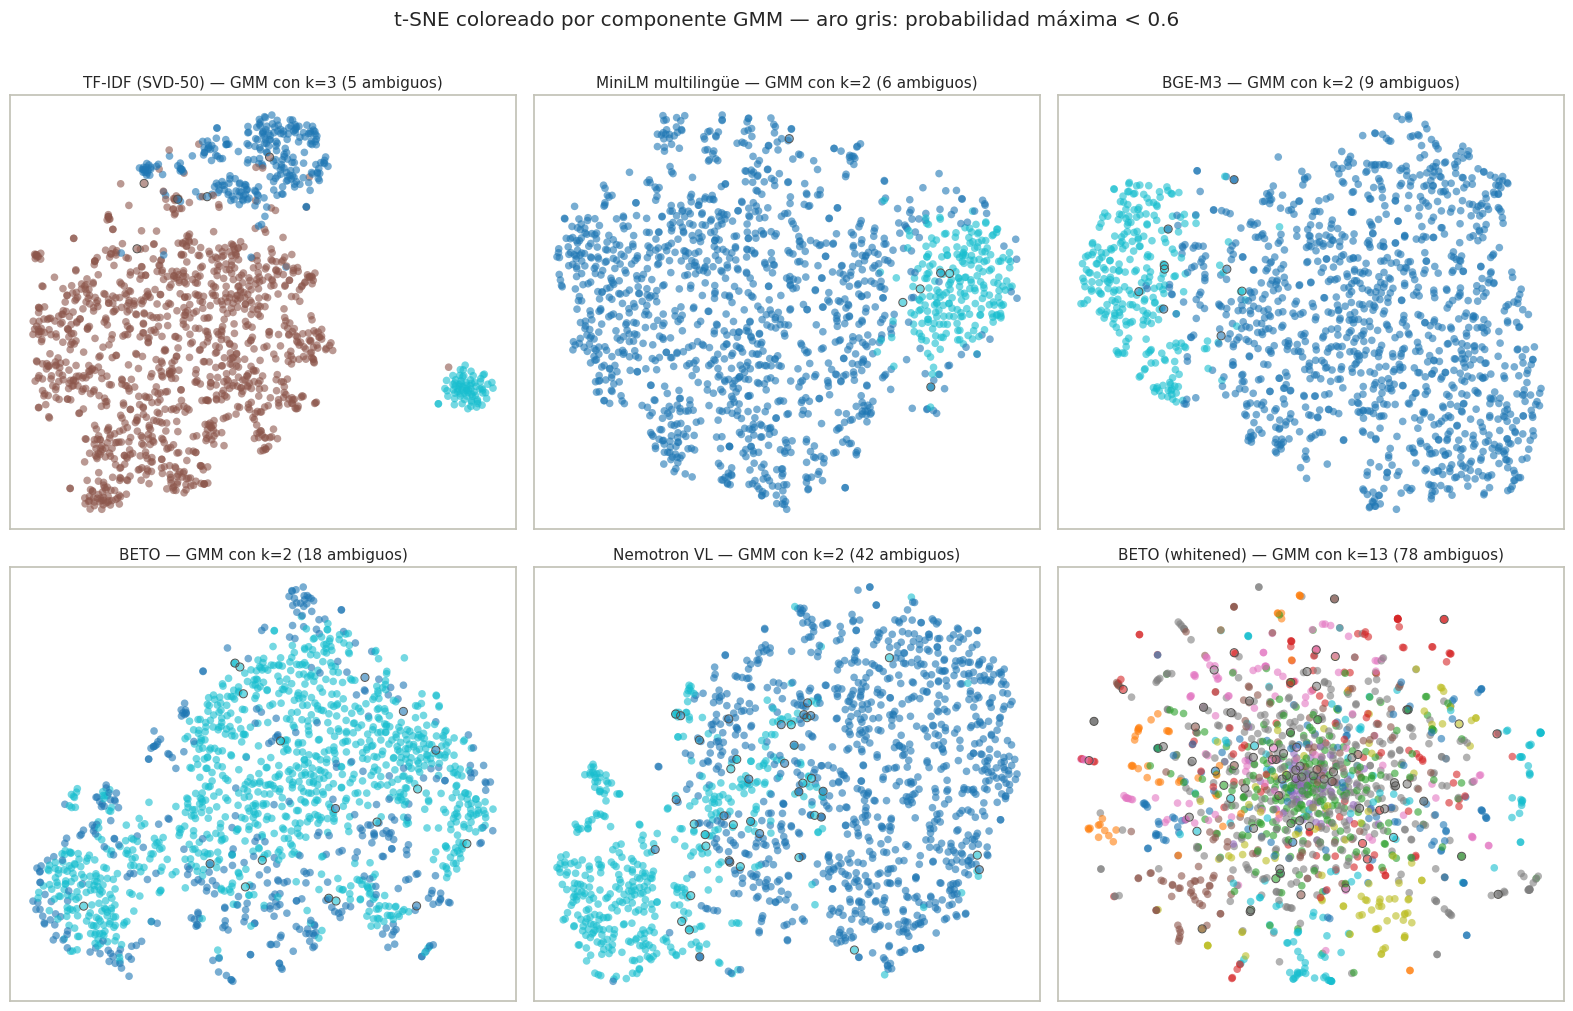

In [18]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

fig, axes = rejilla(len(X_gmm), alto=5)
for ax, nombre in zip(axes, X_gmm):
    emb = embeddings[nombre]
    x50 = emb if emb.shape[1] <= 50 else PCA(n_components=50, random_state=RANDOM_STATE).fit_transform(emb)
    xy = TSNE(n_components=2, init="pca", perplexity=30, max_iter=1000,
              random_state=RANDOM_STATE).fit_transform(x50)
    k = int(mejores.loc[nombre, "k"])
    etiquetas = etiquetas_por_k[(nombre, k)]
    prob_max = resp_por_k[(nombre, k)].max(axis=1)
    ax.scatter(xy[:, 0], xy[:, 1], c=etiquetas, cmap="tab10", s=30, alpha=0.6, linewidths=0)
    ambiguos = prob_max < 0.6
    ax.scatter(xy[ambiguos, 0], xy[ambiguos, 1], facecolors="none",
               edgecolors="#52514e", s=34, linewidths=0.7)
    ax.set_title(f"{nombre} — GMM con k={k} ({ambiguos.sum()} ambiguos)", fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("t-SNE coloreado por componente GMM — aro gris: probabilidad máxima < 0.6", y=1.01)
plt.tight_layout()
plt.show()


## Pertenencias blandas: ¿qué artículos viven entre clústeres?

Esta sección reemplaza al análisis de subclusters de los notebooks HC y es la razón de
usar GMM: cada artículo recibe un vector de probabilidades sobre las k componentes
(responsabilidades), no una etiqueta única. Se resume con tres indicadores en el k
óptimo de cada técnica:

- **prob_max_media** — probabilidad media de la componente ganadora. Cerca de 1, la GMM
  se comporta como una partición dura (tipo k-means) y la ventaja blanda es nula.
- **pct_ambiguos** — porcentaje de artículos cuya **segunda** componente supera
  `UMBRAL_SEGUNDA = 0.25`: artículos genuinamente repartidos entre dos temas.
- **entropia_media** — entropía normalizada media del vector de responsabilidades
  (0 = asignación segura, 1 = repartida uniformemente).


In [19]:
UMBRAL_SEGUNDA = 0.25

filas = []
for nombre in X_gmm:
    k = int(mejores.loc[nombre, "k"])
    P = resp_por_k[(nombre, k)]
    orden = np.sort(P, axis=1)[:, ::-1]
    entropia = -(P * np.log(np.clip(P, 1e-12, None))).sum(axis=1) / np.log(P.shape[1])
    filas.append({
        "tecnica": nombre,
        "k": k,
        "prob_max_media": orden[:, 0].mean(),
        "pct_ambiguos": (orden[:, 1] > UMBRAL_SEGUNDA).mean() * 100,
        "entropia_media": entropia.mean(),
    })

ambiguedad = pd.DataFrame(filas).set_index("tecnica").round(3)
ambiguedad


,k,prob_max_media,pct_ambiguos,entropia_media
tecnica,,,,
TF-IDF (SVD-50),3,0.994,0.728,0.013
MiniLM multilingüe,2,0.987,2.183,0.048
BGE-M3,2,0.988,1.852,0.044
BETO,2,0.977,3.241,0.084
Nemotron VL,2,0.944,8.201,0.198
BETO (whitened),13,0.917,9.127,0.092


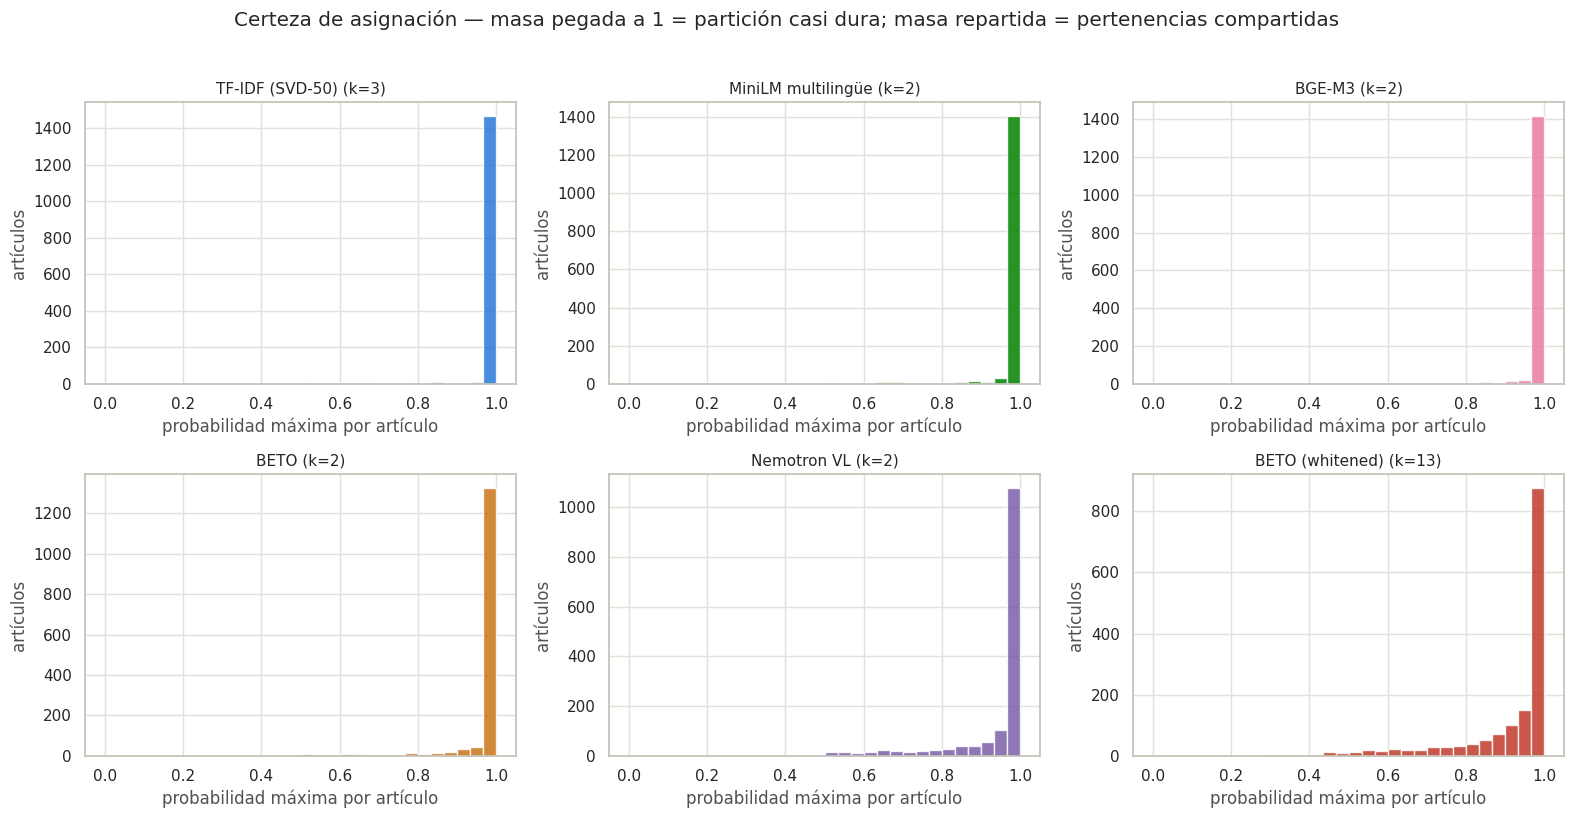

In [20]:
fig, axes = rejilla(len(X_gmm), alto=4.0)
for ax, nombre in zip(axes, X_gmm):
    k = int(mejores.loc[nombre, "k"])
    P = resp_por_k[(nombre, k)]
    ax.hist(P.max(axis=1), bins=30, range=(0, 1), color=COLORES_TEC[nombre], alpha=0.85)
    ax.set_title(f"{nombre} (k={k})", fontsize=11)
    ax.set_xlabel("probabilidad máxima por artículo")
    ax.set_ylabel("artículos")
plt.suptitle("Certeza de asignación — masa pegada a 1 = partición casi dura; "
             "masa repartida = pertenencias compartidas", y=1.02)
plt.tight_layout()
plt.show()


### Artículos de asignación menos segura

Los `N_AMBIGUOS` artículos con menor probabilidad máxima por técnica, con sus dos
componentes más probables. La columna `seccion` permite un primer chequeo manual:
un artículo repartido entre dos componentes cuyos temas son afines (economía/política)
sugiere ambigüedad temática real y no ruido del modelo.


In [21]:
N_AMBIGUOS = 8

tablas = []
for nombre in X_gmm:
    k = int(mejores.loc[nombre, "k"])
    P = resp_por_k[(nombre, k)]
    top2 = np.argsort(P, axis=1)[:, ::-1][:, :2]
    p1 = P[np.arange(len(P)), top2[:, 0]]
    peores = np.argsort(p1)[:N_AMBIGUOS]  # asignación menos segura
    tablas.append(pd.DataFrame({
        "tecnica": nombre,
        "titulo": muestra.loc[peores, "titulo"].fillna("(sin título)").values,
        "seccion": muestra.loc[peores, "seccion"].values,
        "cluster_1": top2[peores, 0] + 1,
        "p1": p1[peores].round(2),
        "cluster_2": top2[peores, 1] + 1,
        "p2": P[peores, top2[peores, 1]].round(2),
    }))

articulos_ambiguos = pd.concat(tablas, ignore_index=True)
with pd.option_context("display.max_colwidth", 90):
    display(articulos_ambiguos)


,tecnica,titulo,seccion,cluster_1,p1,cluster_2,p2
0,TF-IDF (SVD-50),Juleisy Angulo Es La Mejor Atleta De La Temporada 2025,Deportes,1,0.50,2,0.50
1,TF-IDF (SVD-50),El Psg Renuncia A Adquirir El Estadio De Francia,Jugada,1,0.51,2,0.49
2,TF-IDF (SVD-50),El Sistema Se Mantiene Con El Aval De Goltv,Portada,2,0.52,1,0.48
3,TF-IDF (SVD-50),"La Mañana Con Diversión, Concursos Y Colores",Guayaquil,2,0.56,1,0.44
4,TF-IDF (SVD-50),El Detalle,Deportes,2,0.60,1,0.40
5,TF-IDF (SVD-50),Francia Recupera A Extranjeros Que Lucharon En La Resistencia Antinazi,Mundo,2,0.63,1,0.37
6,TF-IDF (SVD-50),"Jefferson Pérez: ""La Medalla De 'Richie' Abre Una Ventana Para Los Demás Atletas""",Jugada,1,0.63,2,0.37
7,TF-IDF (SVD-50),La Realización De La Copa América En Argentina Aún No Está Definida,Jugada,1,0.64,2,0.36
8,MiniLM multilingüe,Ale­xan­der Domín­guez llegó a fir­mar con­trato,Deportes,2,0.52,1,0.48
9,MiniLM multilingüe,"Primoz Roglic Corrió La Etapa 4 Del Tour ""Disfrazado"" De Momia",Jugada,2,0.53,1,0.47


## Títulos descriptivos por clúster (DeepSeek vía vLLM)

Para cada clúster del corte óptimo se toma una **muestra aleatoria de 10 artículos**
(título + inicio del texto) y se pide a `deepseek-ai/DeepSeek-V4-Flash` (servidor H200,
cliente de `src/llm_clients`) un **título descriptivo corto** del tema dominante.
**Requiere VPN GlobalProtect activa.**

Nota: DeepSeek es un modelo de razonamiento — consume parte del presupuesto de
`max_tokens` en el campo `reasoning` antes de emitir `content`, por eso se usa un
límite generoso aunque la respuesta esperada sea corta.

In [22]:
from src.llm_clients import get_chat_client, load_config

config = load_config()
cliente_chat = get_chat_client(config)
N_EJEMPLOS = 10

PROMPT_TITULO = (
    "Eres un analista de prensa ecuatoriana. A continuación tienes una muestra de "
    "artículos (título y primeras líneas) que pertenecen a un mismo clúster temático "
    "obtenido por clustering no supervisado.\n\n{ejemplos}\n\n"
    "Escribe UN solo título descriptivo en español (máximo 10 palabras) que resuma el "
    "tema dominante del clúster. Si los temas son heterogéneos, dilo en el título "
    "(p. ej. 'Actualidad general: política, deportes y sucesos'). "
    "Responde únicamente con el título, sin comillas ni explicaciones."
)


def titular_cluster(indices: np.ndarray) -> str:
    """Pide a DeepSeek un título descriptivo para los artículos indicados."""
    ejemplos = "\n".join(
        f"- {muestra.loc[i, 'titulo'] or '(sin título)'}: "
        f"{muestra.loc[i, 'texto_norm'][:200]}…"
        for i in indices
    )
    respuesta = cliente_chat.chat.completions.create(
        model=config.chat_model,
        messages=[{"role": "user", "content": PROMPT_TITULO.format(ejemplos=ejemplos)}],
        temperature=0.3,
        max_tokens=2000,  # modelo de razonamiento: reserva presupuesto para 'reasoning'
    )
    contenido = respuesta.choices[0].message.content
    return contenido.strip().strip('"') if contenido else "(respuesta vacía)"


In [23]:
from tqdm.auto import tqdm

rng = np.random.default_rng(RANDOM_STATE)
filas = []
for nombre in X_gmm:
    k = int(mejores.loc[nombre, "k"])
    etiquetas = etiquetas_por_k[(nombre, k)]
    for c in tqdm(range(1, k + 1), desc=f"{nombre} (k={k})"):
        indices = np.flatnonzero(etiquetas == c)
        if len(indices) == 0:
            # Con etiquetas duras (argmax) una componente puede quedar sin artículos
            continue
        seleccion = rng.choice(indices, size=min(N_EJEMPLOS, len(indices)), replace=False)
        filas.append({
            "tecnica": nombre,
            "cluster": c,
            "n_articulos": len(indices),
            "titulo_deepseek": titular_cluster(seleccion),
            "ejemplos": " | ".join(muestra.loc[seleccion[:3], "titulo"].fillna("(sin título)")),
        })

titulos_clusters = pd.DataFrame(filas)
with pd.option_context("display.max_colwidth", 120):
    display(titulos_clusters)


TF-IDF (SVD-50) (k=3):   0%|          | 0/3 [00:00<?, ?it/s]

MiniLM multilingüe (k=2):   0%|          | 0/2 [00:00<?, ?it/s]

BGE-M3 (k=2):   0%|          | 0/2 [00:00<?, ?it/s]

BETO (k=2):   0%|          | 0/2 [00:00<?, ?it/s]

Nemotron VL (k=2):   0%|          | 0/2 [00:00<?, ?it/s]

BETO (whitened) (k=13):   0%|          | 0/13 [00:00<?, ?it/s]

,tecnica,cluster,n_articulos,titulo_deepseek,ejemplos
0,TF-IDF (SVD-50),1,264,"Fútbol ecuatoriano: selección, liga y jugadores",John Yeboah Ante El Reto De Su Vida: Intentar Derrotar A La Selección Del País Donde Nació Para Seguir En El Mundial...
1,TF-IDF (SVD-50),2,1173,"Actualidad general: política, cultura, deportes y conflictos",Nuevos Combates Entre Tailandia Y Camboya | Prepararse Para El Examen Ciudadano | Resignificando El Bicentenario
2,TF-IDF (SVD-50),3,75,"Heterogéneo: economía, deportes, sociedad y sucesos",FESTIVAL DE LAS FLORES | AZÚCAR | Con vacuna o no hay ni gim­na­sio
3,MiniLM multilingüe,1,1277,"Noticias variadas: política, clima, tecnología y sociedad",Sectores Del Norte De Guayaquil Quedaron Inundados Por Intensa Lluvia | Captar Música Por Medio Del Tacto | Vía Cuen...
4,MiniLM multilingüe,2,235,"Actualidad deportiva: fútbol, tenis y ciclismo",¡Oficial! Alineaciones De Racing Y Cruzeiro Para La Final De La Copa Sudamericana 2024 | ¡Gran Exhibición! Juan Mart...
5,BGE-M3,1,1232,"Actualidad general: política, economía, sociedad y sucesos",Arribó Grupo De Deportados Desde Ee. Uu. | Anun­cia la mar­cha de su direc­tor finan­ciero | La Reforma Y Su Impacto...
6,BGE-M3,2,280,Deportes: fútbol ecuatoriano e internacional,"Polé­mica por la roja a Cabeza | Ecuatorianos En Torneos Coperos. | ‘Muchachos, La Película De La Gente’, Llena De P..."
7,BETO,1,411,"Actualidad general: política, deportes y sucesos","Alan Franco, la MLS lo quiere con­tra­tar | Informales Obstaculizan La Circulación Vehicular | FUNDACIÓN REMODELA CA..."
8,BETO,2,1101,"Actualidad variada: política, deportes, salud y sociedad","Malecón 3000: Municipio Frena Las Expropiaciones En Samanes | Juegos, Fiestas, Pérdida De Tiempo En Centros De Estud..."
9,Nemotron VL,1,1038,"Actualidad general: política, sociedad, tecnología y ambiente",Circulan Hoy Placas Que Terminan En | Deslumbrados Pero No Ciegos | Fiscalía Acusa A Celi De Posible Cohecho


### Lectura temática de los artículos ambiguos

Se cruzan los artículos de asignación menos segura con los títulos DeepSeek de sus dos
componentes más probables. Si los pares de temas son afines (p. ej. economía ↔ política),
la ambigüedad es genuina y valida la elección de un modelo blando; si los pares parecen
arbitrarios, la incertidumbre es ruido del ajuste y no estructura temática.


In [24]:
titulos_idx = titulos_clusters.set_index(["tecnica", "cluster"])["titulo_deepseek"]
ambiguos_titulados = articulos_ambiguos.assign(
    tema_1=[titulos_idx.get((t, c), "(componente sin artículos)")
            for t, c in zip(articulos_ambiguos["tecnica"], articulos_ambiguos["cluster_1"])],
    tema_2=[titulos_idx.get((t, c), "(componente sin artículos)")
            for t, c in zip(articulos_ambiguos["tecnica"], articulos_ambiguos["cluster_2"])],
)[["tecnica", "titulo", "p1", "tema_1", "p2", "tema_2"]]
with pd.option_context("display.max_colwidth", 70):
    display(ambiguos_titulados)


,tecnica,titulo,p1,tema_1,p2,tema_2
0,TF-IDF (SVD-50),Juleisy Angulo Es La Mejor Atleta De La Temporada 2025,0.50,"Fútbol ecuatoriano: selección, liga y jugadores",0.50,"Actualidad general: política, cultura, deportes y conflictos"
1,TF-IDF (SVD-50),El Psg Renuncia A Adquirir El Estadio De Francia,0.51,"Fútbol ecuatoriano: selección, liga y jugadores",0.49,"Actualidad general: política, cultura, deportes y conflictos"
2,TF-IDF (SVD-50),El Sistema Se Mantiene Con El Aval De Goltv,0.52,"Actualidad general: política, cultura, deportes y conflictos",0.48,"Fútbol ecuatoriano: selección, liga y jugadores"
3,TF-IDF (SVD-50),"La Mañana Con Diversión, Concursos Y Colores",0.56,"Actualidad general: política, cultura, deportes y conflictos",0.44,"Fútbol ecuatoriano: selección, liga y jugadores"
4,TF-IDF (SVD-50),El Detalle,0.60,"Actualidad general: política, cultura, deportes y conflictos",0.40,"Fútbol ecuatoriano: selección, liga y jugadores"
5,TF-IDF (SVD-50),Francia Recupera A Extranjeros Que Lucharon En La Resistencia Anti...,0.63,"Actualidad general: política, cultura, deportes y conflictos",0.37,"Fútbol ecuatoriano: selección, liga y jugadores"
6,TF-IDF (SVD-50),"Jefferson Pérez: ""La Medalla De 'Richie' Abre Una Ventana Para Los...",0.63,"Fútbol ecuatoriano: selección, liga y jugadores",0.37,"Actualidad general: política, cultura, deportes y conflictos"
7,TF-IDF (SVD-50),La Realización De La Copa América En Argentina Aún No Está Definida,0.64,"Fútbol ecuatoriano: selección, liga y jugadores",0.36,"Actualidad general: política, cultura, deportes y conflictos"
8,MiniLM multilingüe,Ale­xan­der Domín­guez llegó a fir­mar con­trato,0.52,"Actualidad deportiva: fútbol, tenis y ciclismo",0.48,"Noticias variadas: política, clima, tecnología y sociedad"
9,MiniLM multilingüe,"Primoz Roglic Corrió La Etapa 4 Del Tour ""Disfrazado"" De Momia",0.53,"Actualidad deportiva: fútbol, tenis y ciclismo",0.47,"Noticias variadas: política, clima, tecnología y sociedad"


## Lectura de resultados

- La comparación directa es contra `hc_clustering.ipynb`: mismas técnicas, misma
  submuestra y mismas métricas sobre el mismo espacio; la única diferencia es el
  algoritmo (Ward vs. GMM) y la reducción PCA previa que la GMM exige. Diferencias en
  silhouette/ARI/AMI se atribuyen a eso.
- **k por silhouette vs. k por BIC**: si el BIC pide sistemáticamente más componentes
  que silhouette, la GMM está usando varias gaussianas para modelar la densidad de una
  misma nube temática (los embeddings L2-normalizados viven sobre una hiperesfera, no
  son gaussianos) — no significa que haya más temas.
- El veredicto sobre la motivación del notebook está en `pct_ambiguos` y en la tabla de
  artículos ambiguos titulada: si la masa de probabilidad máxima está pegada a 1, la GMM
  degenera en una partición dura y no aporta nada sobre HC; si hay una fracción
  apreciable de artículos repartidos entre componentes **temáticamente afines**, el soft
  clustering captura estructura real que HC pierde por construcción.
- Antes de premiar un silhouette alto, revisar el **η² de longitud**, igual que en HC:
  la lectura del contraste BETO vs. Nemotron VL es la misma.
- Calinski-Harabasz no es comparable **entre** técnicas (depende de la escala del
  espacio); úsese solo dentro de una misma técnica.
- Este resultado alimenta, junto con los notebooks HC, la decisión del método de
  embedding y de clustering definitivos para el pipeline con Milvus.
